In [1]:
from synthetic_data_generator import create_fesom_matrix
from GNP import GNP, scale_A_by_spectral_radius
from ResGCN import ResGCN
from GMRES import GMRES
from scipy.sparse import csc_matrix, identity
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import xarray as xr
import math

# Hierarchichal training

In our case we can make problem gradually more difficult to solve, while keeping the the `A` matrix in exactly the same shape. This should allow us to use the same `ResGCN`

- First way is to increase the scale of the filter, as the bigger scacle the worse is the conditioning of the matrix. 
- Second is increasing the order of the filer `n`, which makes much more difficult to solve the problem
---

To start we have to generate sythetic problem of given size

In [2]:
# --- FESOM data setup (replaces synthetic) ---
import numpy as np
import xarray as xr
import torch
import matplotlib as mpl

# device (only if you don't already define it elsewhere)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths
MESH_PATH = "/work/ab0995/a270225/atmorep_data/multiverse/core2/original/cycle_1/fesom.mesh.diag.nc"
SST_PATH  = "/work/ab0995/a270225/atmorep_data/multiverse/core2/original/cycle_1/sst.fesom.2000.nc"

# Load mesh
mesh = xr.open_dataset(MESH_PATH)

# Coordinates (1D arrays of node positions)
xcoord = mesh["lon"].values
ycoord = mesh["lat"].values

# Triangles: FESOM meshes are typically 1-based; shift to 0-based for numpy/mpl
# face_nodes usually has shape (3, ntri) — transpose to (ntri, 3)
tri = mesh["face_nodes"].T.values - 1

# Optionally build any precomputed matrices/indices you need
from synthetic_data_generator import create_fesom_matrix
ss, ii, jj, tri, xcoord, ycoord = create_fesom_matrix(xcoord, ycoord, tri)

# Mask triangles that wrap the dateline for cleaner plotting
ok = (xcoord[tri].max(axis=1) - xcoord[tri].min(axis=1)) < 10
triang = mpl.tri.Triangulation(xcoord, ycoord, tri[ok, :])

# Dimensionality (number of 2D surface nodes)
n2d = xcoord.shape[0]

# Load SST and pick a single time slice as the target vector
ds = xr.open_dataset(SST_PATH)

# pick the variable (change 'sst' if your file uses a different name)
var_name = "sst" if "sst" in ds.data_vars else list(ds.data_vars)[0]
data_da = ds[var_name]        # expected shape: (time, node)

time_index = 0                # choose which timestep to use
tt = data_da.isel(time=time_index).values  # numpy array, shape (n2d,)

# Torch tensor expected downstream
data = torch.tensor(tt, device=device, dtype=torch.float64)

# --- End FESOM data setup ---


In [3]:
# --- FESOM data setup (replaces synthetic) ---
import numpy as np
import xarray as xr
import torch
import matplotlib as mpl

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths (as in fesom_data.ipynb)
MESH_PATH = "/work/ab0995/a270225/atmorep_data/multiverse/core2/original/cycle_1/fesom.mesh.diag.nc"
SST_PATH  = "/work/ab0995/a270225/atmorep_data/multiverse/core2/original/cycle_1/sst.fesom.2000.nc"

# --- Mesh and operator ---
mesh = xr.open_dataset(MESH_PATH)

# FESOM coordinates and triangles
xcoord = mesh["lon"].values      # shape: (n2d,)
ycoord = mesh["lat"].values      # shape: (n2d,)
tri    = mesh["face_nodes"].T.values - 1  # (ntri, 3), 0-based

# number of surface nodes
n2d = xcoord.shape[0]

# build FESOM smoothing matrix (same call as in fesom_data.ipynb)
ss, ii, jj, tri, xcoord, ycoord = create_fesom_matrix(xcoord, ycoord, tri)

# --- SST data as RHS/target vector ---
ds = xr.open_dataset(SST_PATH)
sst = ds["sst"]                  # dims: (time, node) or similar

time_index = 0
tt = sst.isel(time=time_index).values  # shape should be (n2d,)

# move to torch, used later as `data`
data = torch.tensor(tt, device=device, dtype=torch.float64)

# --- End FESOM data setup ---



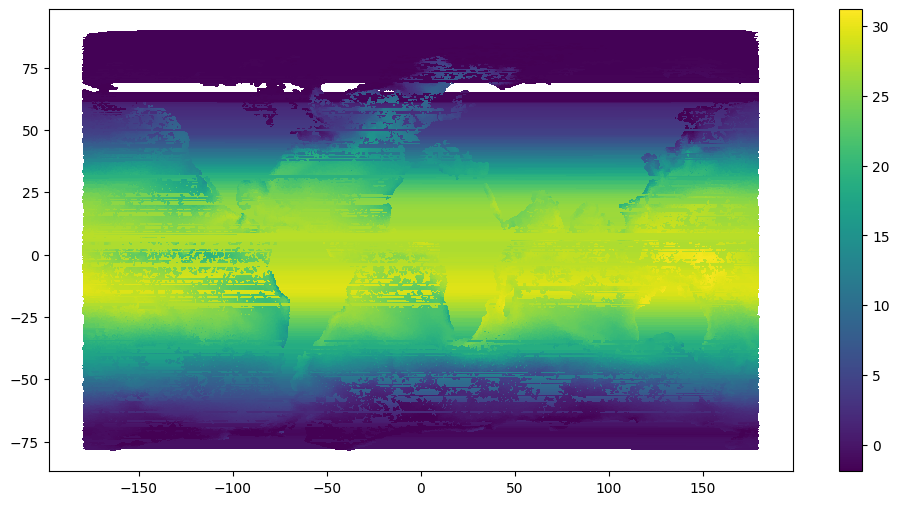

In [4]:
plt.rcParams['figure.figsize'] = [12, 6]
triang = mpl.tri.Triangulation(xcoord, ycoord, tri)

plt.tripcolor(triang, tt)
plt.colorbar()

Now lets define model parameters 

In [5]:
num_layers = 8              # number of layers in GNP
embed = 32                  # embedding dimension in GNP
hidden = 64                 # hidden dimension in MLPs in GNP
drop_rate = 0.05            # dropout rate in GNP
disable_scale_input = False # whether disable the scaling of inputs in GNP
dtype = torch.float64       # training precision for GNP
lr = 2e-3                   # learning rate in training GNP
weight_decay = 0.0          # weight decay in training GNP
training_data = 'x_mix'     # type of training data x
m = 80                      # Krylov subspace dimension for training data
batch_size = 4              # batch size in training GNP
grad_accu_steps = 1         # gradient accumulation steps in training GNP
epochs = 1000               # number of epochs in training GNP 

Now we need to create scales that we want to use

In [6]:
kc = 2 * math.pi / np.logspace(1, 3, 10) # 10 values from 10 to 1000 km

In [7]:
tt.shape

(126858,)

Now we define the matricies for model to learn preconditioning

In [8]:
n = 1 # Filter order
device = torch.device("cuda")
solver = GMRES()
As = []

for k in kc: # Looping over the scales
    Smat1 = csc_matrix((ss * (1.0 / np.square(k)), (ii, jj)), shape=(n2d, n2d))
    Smat = identity(n2d) + 2.0 * (Smat1 ** n)
    A = torch.sparse_csc_tensor(Smat.indptr, Smat.indices, Smat.data, Smat.shape, dtype=torch.float64).to(device)
    A = scale_A_by_spectral_radius(A)
    As += [A]
    
data = torch.tensor(np.array(tt), device=device, dtype=torch.float64)

/tmp/ipykernel_366785/641305269.py:9: UserWarning: Sparse CSC tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  A = torch.sparse_csc_tensor(Smat.indptr, Smat.indices, Smat.data, Smat.shape, dtype=torch.float64).to(device)


Now model can be initialized for the first phase of training

In [9]:
net = ResGCN(As[-1], num_layers, embed, hidden, drop_rate, scale_input=True, dtype=dtype).to(device)
optimizer = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = None
M = GNP(A, training_data, m, net, device)

As a test we will solve the problem without preconditioner 

In [10]:
iterations = np.zeros(len(As))

for i in range(len(As)):
    ttw = data - As[i] @ data  # Work with perturbations
    x, iters, _, _, _ = solver.solve(A=As[i], b=ttw, rtol=1e-6, max_iters=19999, progress_bar=True)
    print("Iteration " + str(iters))
    iterations[i] = iters

Solve:   0%|          | 41/19999 [00:00<04:34, 72.74it/s]


Iteration 41


Solve:   0%|          | 85/19999 [00:00<00:39, 507.11it/s]


Iteration 85


Solve:   1%|          | 200/19999 [00:00<00:34, 568.11it/s]


...

Iteration 19999


Solve: 100%|██████████| 19999/19999 [00:33<00:00, 588.99it/s]


Iteration 19999


Solve: 100%|██████████| 19999/19999 [00:35<00:00, 563.83it/s]

Iteration 19999


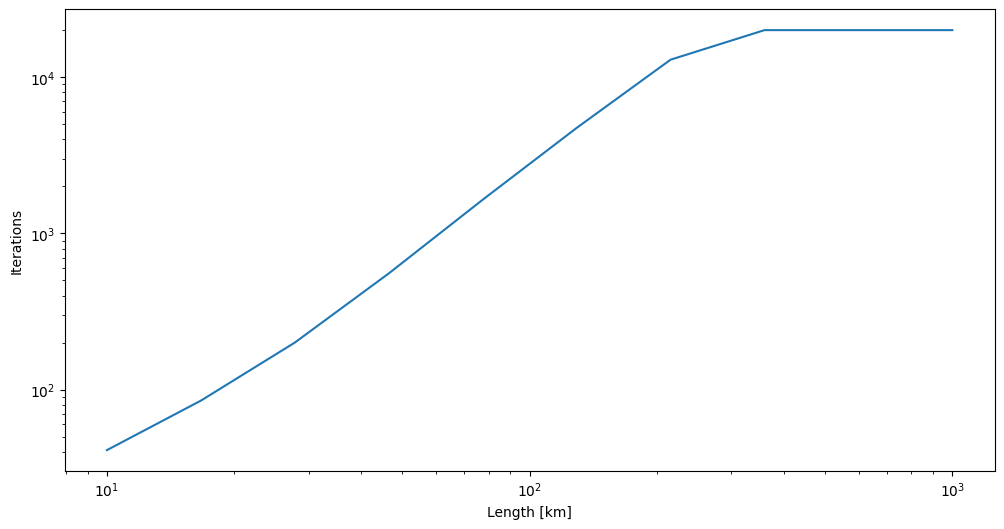

In [11]:
plt.plot(np.logspace(1, 3, 10), iterations)
plt.xlabel("Length [km]")
plt.ylabel("Iterations")
plt.xscale("log")
plt.yscale("log")

In [12]:
#OPTUNA Installation cell required to run notebook in different environments and kernels

In [13]:
%pip install optuna
%pip install --upgrade jupyter jupyterlab notebook


/home/a/a270285/.conda/envs/NaomiKernel/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [14]:
### OPTUNA AND TASK 1&2 First Try

### How to vary phases and vary A(s)

In [15]:
# === Cell 1: Optuna objective with Tasks 1&2 (fixed 8 phases, FAST) ===
import gc, time, optuna
from optuna.pruners import MedianPruner
import torch
import torch.nn.functional as F

def _free_cuda():
    torch.cuda.empty_cache(); gc.collect()

def _dtype_from_name(name: str):
    return torch.float64 if "64" in name else torch.float32

# Choose GROWTH
_GROWTH_E = 1.06
_GROWTH_M = 1.06
_GROWTH_B = 1.06

# Choose PHASES and EPOCHS and _AS_SUBSET for variaton
# NOT included in hyperparameter tuning, as significant computation time increase for non-guaranteed speed-up
# each phase trains on the first _AS_SUBSET graphs; set _AS_SUBSET = len(As) to use all graphs each phase
_AS_SUBSET = 2
_MAX_PHASES = 30         
_CAP_EPOCHS = 250         
_CAP_M      = 80        
_CAP_BATCH  = 12          


def objective(trial: optuna.Trial):
    # Vary ALL
    num_layers_          = trial.suggest_int("num_layers", 4, 16, step=2)
    embed_               = trial.suggest_categorical("embed", [16, 32, 48, 64])
    hidden_              = trial.suggest_categorical("hidden", [64, 96, 128, 192, 256])
    drop_rate_           = trial.suggest_float("drop_rate", 0.0, 0.4, step=0.05)
    disable_scale_input_ = trial.suggest_categorical("disable_scale_input", [False, True])
    dtype_name_          = trial.suggest_categorical("dtype", ["float32", "float64"])
    lr_                  = trial.suggest_float("lr", 5e-4, 5e-3, log=True)
    weight_decay_        = trial.suggest_float("weight_decay", 0.0, 1e-2, log=False)  # allow exact 0
    training_data_       = trial.suggest_categorical("training_data", ["x_mix", "x_subspace", "x_random"])
    m_                   = trial.suggest_int("m", 20, 80, step=10)
    batch_size_          = trial.suggest_categorical("batch_size", [1, 2, 4])
    grad_accu_steps_     = trial.suggest_categorical("grad_accu_steps", [1, 2, 4])
    epochs_              = trial.suggest_int("epochs", 60, 200)  # serves as BASE epochs
    phases_              = trial.suggest_int("phases", 1, _MAX_PHASES)
    dtype_ = _dtype_from_name(dtype_name_)

    # keep float64 trials lighter (CHATGPT)
    if dtype_ == torch.float64:
        m_ = min(m_, 40)
        batch_size_ = min(batch_size_, 2)

    # build model once in the sampled dtype; init on smallest graph
    A0 = As[0]
    net = ResGCN(
        A0,
        num_layers=num_layers_, embed=embed_, hidden=hidden_,
        drop_rate=drop_rate_, scale_input=(not disable_scale_input_), dtype=dtype_
    ).to(device).to(dtype_)

    optimizer = torch.optim.AdamW(net.parameters(), lr=lr_, weight_decay=weight_decay_)

    M_tune = GNP(A0, training_data_, m_, net, device)
    if hasattr(M_tune, "dtype"):
        M_tune.dtype = dtype_

    best_overall = float("inf")
    pruner_step = 0

    try:
        # Tasks 1&2: vary phases and subsets, each phase varies over _AS_SUBSET=K graphs which can be changed 
        total_phases = _MAX_PHASES
        As_fast = As[:min(_AS_SUBSET, len(As))]

        for phase in range(total_phases):
            # per-phase growth from the *trial* bases, then clamp to caps
            epochs_now = int(round(epochs_     * (_GROWTH_E ** phase)))
            m_now      = int(round(m_          * (_GROWTH_M ** phase)))
            batch_now  = int(round(batch_size_ * (_GROWTH_B ** phase)))

            epochs_now = max(1, min(_CAP_EPOCHS, epochs_now))
            M_tune.m   = max(1, min(_CAP_M,     m_now))
            batch_now  = max(1, min(_CAP_BATCH, batch_now))

            for i, Ai in enumerate(As_fast):
                M_tune.A = Ai

                # no checkpointing during search to keep trials light
                hist_loss, best_loss, best_epoch, _ = M_tune.train(
                    batch_size=batch_now,
                    grad_accu_steps=grad_accu_steps_,
                    epochs=epochs_now,
                    optimizer=optimizer,
                    scheduler=None,
                    num_workers=0,
                    checkpoint_prefix_with_path=None,
                    progress_bar=False,
                )

                metric = float(best_loss) if len(hist_loss) else float('inf')
                best_overall = min(best_overall, metric)

                pruner_step += 1
                trial.report(metric, pruner_step)
                if trial.should_prune():
                    raise optuna.exceptions.TrialPruned()

        return best_overall

    except RuntimeError as e:
        if "CUDA out of memory" in str(e):
            _free_cuda()
            raise optuna.exceptions.TrialPruned() from e
        raise
    finally:
        del net, optimizer, M_tune
        _free_cuda()


In [16]:
# Cell 2: Study setup (safe seeding) + globals update (+schedule) 
sampler = optuna.samplers.TPESampler(n_startup_trials=10, multivariate=True, group=True)
pruner  = MedianPruner(n_warmup_steps=2)

study = optuna.create_study(
    study_name="gnp_hparam_search",
    direction="minimize",
    sampler=sampler,
    pruner=pruner,
    # storage="sqlite:///gnp_optuna.db", load_if_exists=True,
)

# SAFE SEED VALUES (use existing if present, else defaults) 
seed_epochs = int(min(120, int(globals().get("_CAP_EPOCHS", 200))))
seed_phases = int(globals().get(1, _MAX_PHASES))

# seed with current globals + safe schedule seeds
study.enqueue_trial({
    "num_layers": num_layers,
    "embed": embed,
    "hidden": hidden,
    "drop_rate": drop_rate,
    "disable_scale_input": disable_scale_input,
    "dtype": "float64" if dtype == torch.float64 else "float32",
    "lr": lr,
    "weight_decay": weight_decay,
    "training_data": training_data,
    "m": m,
    "batch_size": batch_size,
    "grad_accu_steps": grad_accu_steps,
    "epochs": seed_epochs,  
    "phases": seed_phases,  
})

# choose amount of trials
study.optimize(objective, n_trials=12, gc_after_trial=True, show_progress_bar=True)

print(f"\n[Optuna] Trials: {len(study.trials)}  Best value: {study.best_value:.6e}")
print("[Optuna] Best hyperparameters:")
for k, v in study.best_trial.params.items():
    print(f"  {k}: {v}")

best = study.best_trial.params

# Update core 
num_layers = int(best["num_layers"])
embed = int(best["embed"])
hidden = int(best["hidden"])
drop_rate = float(best["drop_rate"])
disable_scale_input = bool(best["disable_scale_input"])
dtype = torch.float64 if best["dtype"] == "float64" else torch.float32
lr = float(best["lr"])
weight_decay = float(best["weight_decay"])
training_data = str(best["training_data"])
m = int(best["m"])
batch_size = int(best["batch_size"])
grad_accu_steps = int(best["grad_accu_steps"])

# Export schedule knobs for the training cell
# Use tuned 'epochs' and 'phases' if present; otherwise keep the seed values.
PHASES = int(best.get("phases", seed_phases))
EPOCHS_PER_PHASE_BASE = int(best.get("epochs", seed_epochs))
M_BASE = int(best.get("m", m))
BATCH_BASE = int(best.get("batch_size", batch_size))

# Keep these consistent with Cell 1 FAST settings:
GROWTH_EPOCHS = 1.06
GROWTH_M = 1.06
GROWTH_BATCH = 1.06
MAX_EPOCHS_PER_PHASE = 40
MAX_M = 512
MAX_BATCH = 4

# Runtime knobs used by the training cell
CKPT_DIR = "./checkpoints_tasks12"
SAVE_BEST_EACH_PASS = True
RESUME_FROM_PHASE = 0

print("\n[Optuna] Globals updated (+schedule).")
print(f"[Schedule] PHASES={PHASES}, EPOCHS_BASE={EPOCHS_PER_PHASE_BASE}, "
      f"M_BASE={M_BASE}, BATCH_BASE={BATCH_BASE}, "
      f"GROWTH(E,M,B)=({GROWTH_EPOCHS},{GROWTH_M},{GROWTH_BATCH}), "
      f"MAX(E,M,B)=({MAX_EPOCHS_PER_PHASE},{MAX_M},{MAX_BATCH})")



/home/a/a270285/.conda/envs/NaomiKernel/lib/python3.12/site-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
/home/a/a270285/.conda/envs/NaomiKernel/lib/python3.12/site-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2025-11-17 12:06:47,914] A new study created in memory with name: gnp_hparam_search


  0%|          | 0/12 [00:00<?, ?it/s]

[I 2025-11-17 12:25:14,620] Trial 0 finished with value: 0.002478060092509853 and parameters: {'num_layers': 8, 'embed': 32, 'hidden': 64, 'drop_rate': 0.05, 'disable_scale_input': False, 'dtype': 'float64', 'lr': 0.002, 'weight_decay': 0.0, 'training_data': 'x_mix', 'm': 80, 'batch_size': 4, 'grad_accu_steps': 1, 'epochs': 120, 'phases': 30}. Best is trial 0 with value: 0.002478060092509853.
[I 2025-11-17 13:10:09,819] Trial 1 finished with value: 0.004644879139959812 and parameters: {'num_layers': 12, 'embed': 64, 'hidden': 128, 'drop_rate': 0.35000000000000003, 'disable_scale_input': True, 'dtype': 'float32', 'lr': 0.0012578604083809642, 'weight_decay': 0.005546944397302156, 'training_data': 'x_mix', 'm': 30, 'batch_size': 2, 'grad_accu_steps': 1, 'epochs': 186, 'phases': 1}. Best is trial 0 with value: 0.002478060092509853.
[I 2025-11-17 13:18:40,687] Trial 2 finished with value: 0.0040802996044193305 and parameters: {'num_layers': 6, 'embed': 16, 'hidden': 64, 'drop_rate': 0.1, 'd

In [17]:
# Final Tasks 1&2 training (uses globals set by Optuna Cell 2) 
import os, time, gc, numpy as np, torch

# minimal sanity
assert 'As' in globals() and len(As) > 0
assert 'ResGCN' in globals() and 'GNP' in globals()
assert 'device' in globals()

# build model
net = ResGCN(
    As[0], num_layers, embed, hidden, drop_rate,
    scale_input=(not disable_scale_input), dtype=dtype
).to(device).to(dtype)

optimizer = torch.optim.AdamW(net.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = None

M = GNP(As[0], training_data, M_BASE, net, device)
if hasattr(M, "dtype"): M.dtype = dtype

os.makedirs(CKPT_DIR, exist_ok=True)
NUM_WORKERS = 0

t0 = time.time()
for phase in range(RESUME_FROM_PHASE, PHASES):
    # per-phase growth 
    epochs_now = int(max(1, min(MAX_EPOCHS_PER_PHASE, round(EPOCHS_PER_PHASE_BASE * (GROWTH_EPOCHS ** phase)))))
    M.m        = int(max(1, min(MAX_M,                round(M_BASE                * (GROWTH_M      ** phase)))))
    batch_now  = int(max(1, min(MAX_BATCH,            round(BATCH_BASE            * (GROWTH_BATCH  ** phase)))))

    print(f"\n=== PHASE {phase+1}/{PHASES} === [epochs={epochs_now}, batch={batch_now}, m={M.m}]")
    tic = time.time()

    for i, Ai in enumerate(As):
        gc.collect()
        M.A = Ai  # <-- refresh graph for this pass
        ckpt_prefix = os.path.join(CKPT_DIR, f"p{phase:04d}_Ai{i:03d}_")

        hist_loss, best_loss, best_epoch, model_file = M.train(
            batch_now, grad_accu_steps, epochs_now,
            optimizer, scheduler,
            num_workers=NUM_WORKERS,
            checkpoint_prefix_with_path=(ckpt_prefix if SAVE_BEST_EACH_PASS else None),
            progress_bar=False
        )

        # optional reload of best
        if SAVE_BEST_EACH_PASS:
            candidates = []
            if model_file: candidates.append(model_file)
            candidates += [f"{ckpt_prefix}epoch_{best_epoch}.pt", f"{ckpt_prefix}best.pt"]
            for wpath in candidates:
                if wpath and os.path.exists(wpath):
                    try:
                        state = torch.load(wpath, map_location=device, weights_only=True)
                    except TypeError:
                        state = torch.load(wpath, map_location=device)
                    if isinstance(M.net, torch.nn.Module):
                        M.net.load_state_dict(state)
                    break

        try:
            init_loss, final_loss = float(hist_loss[0]), float(hist_loss[-1])
        except Exception:
            init_loss = final_loss = np.nan
        print(f"  Ai {i:03d} | init={init_loss:.4e}, final={final_loss:.4e}, best={float(best_loss):.4e}@{best_epoch}")
        del hist_loss, best_loss, best_epoch, model_file

    torch.save(M.net.state_dict(), os.path.join(CKPT_DIR, f"phase_{phase:04d}_end.pt"))
    print(f"[phase {phase+1}] {time.time()-tic:.2f}s")

print(f"\n[Tasks 1+2] Completed in {time.time()-t0:.2f}s.")



=== PHASE 1/5 === [epochs=40, batch=4, m=80]
  Ai 000 | init=1.7828e-02, final=9.2962e-03, best=7.8931e-03@31
  Ai 001 | init=9.6006e-03, final=7.3865e-03, best=6.9850e-03@30
  Ai 002 | init=8.7042e-03, final=6.4083e-03, best=6.1245e-03@37
  Ai 003 | init=7.0717e-03, final=7.0883e-03, best=5.4256e-03@11
  Ai 004 | init=6.9349e-03, final=5.9068e-03, best=5.5333e-03@38
  Ai 005 | init=5.6372e-03, final=6.7744e-03, best=5.5922e-03@38
  Ai 006 | init=6.8777e-03, final=7.2561e-03, best=4.8977e-03@19
  Ai 007 | init=5.9836e-03, final=8.2603e-03, best=5.4172e-03@5
  Ai 008 | init=6.0822e-03, final=6.4719e-03, best=4.8234e-03@32
  Ai 009 | init=5.5870e-03, final=6.6953e-03, best=5.0748e-03@25
[phase 1] 50.67s

=== PHASE 2/5 === [epochs=40, batch=4, m=85]
  Ai 000 | init=6.0312e-03, final=4.9924e-03, best=4.2142e-03@17
  Ai 001 | init=6.3745e-03, final=5.6016e-03, best=4.7384e-03@18
  Ai 002 | init=5.5791e-03, final=5.3507e-03, best=5.0714e-03@33
  Ai 003 | init=7.3904e-03, final=8.3863e-03, b


=== PHASE 1/5 === [epochs=40, batch=4, m=80]
  Ai 000 | init=1.7589e-02, final=7.4751e-03, best=7.1930e-03@38
  Ai 001 | init=8.6037e-03, final=8.4332e-03, best=6.1711e-03@36
  Ai 002 | init=7.7312e-03, final=8.3311e-03, best=5.6333e-03@26
  Ai 003 | init=7.3876e-03, final=6.8382e-03, best=5.4571e-03@6
  Ai 004 | init=7.3019e-03, final=6.2648e-03, best=5.5899e-03@13
  Ai 005 | init=6.9562e-03, final=8.4184e-03, best=5.8069e-03@9
  Ai 006 | init=5.6490e-03, final=5.1738e-03, best=5.1738e-03@39
  Ai 007 | init=6.4940e-03, final=6.1122e-03, best=5.2989e-03@2
  Ai 008 | init=6.2000e-03, final=6.7291e-03, best=5.1924e-03@16
  Ai 009 | init=6.4657e-03, final=5.8018e-03, best=5.2051e-03@23
[phase 1] 50.58s

=== PHASE 2/5 === [epochs=40, batch=4, m=85]
  Ai 000 | init=5.8639e-03, final=4.9415e-03, best=4.5163e-03@35
  Ai 001 | init=6.6738e-03, final=8.2985e-03, best=4.7855e-03@18
  Ai 002 | init=6.5503e-03, final=6.5177e-03, best=5.7012e-03@10
  Ai 003 | init=7.4461e-03, final=5.8494e-03, bes

Solve: 100%|██████████| 2000/2000 [00:36<00:00, 55.44it/s]


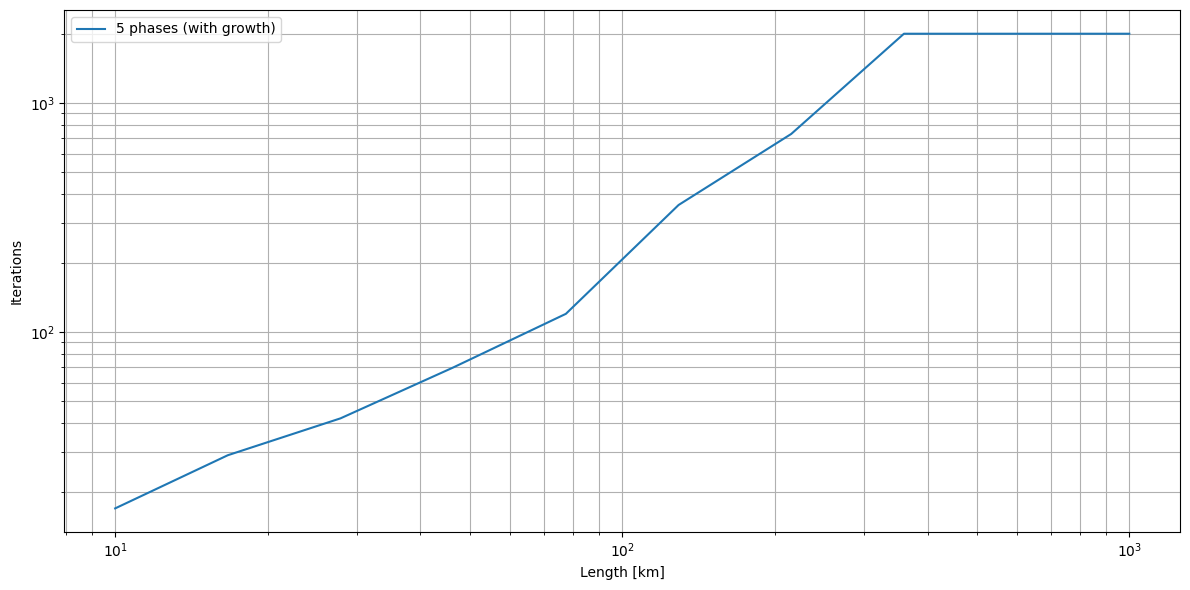

In [18]:
# Final Tasks 1&2 training (uses globals set by Optuna Cell 2) + logging + plots
import os, time, gc, numpy as np, torch
import matplotlib.pyplot as plt

# minimal sanity
assert 'As' in globals() and len(As) > 0
assert 'ResGCN' in globals() and 'GNP' in globals()
assert 'device' in globals()

# build model
net = ResGCN(
    As[0], num_layers, embed, hidden, drop_rate,
    scale_input=(not disable_scale_input), dtype=dtype
).to(device).to(dtype)

optimizer = torch.optim.AdamW(net.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = None

M = GNP(As[0], training_data, M_BASE, net, device)
if hasattr(M, "dtype"): 
    M.dtype = dtype

os.makedirs(CKPT_DIR, exist_ok=True)
NUM_WORKERS = 0

# accumulators for learning curve (mean over As) (Does not work and is not important, yet I thought I might try)
phase_mean_init  = []
phase_mean_final = []
phase_mean_best  = []
phase_best_epoch = []

t0 = time.time()
for phase in range(RESUME_FROM_PHASE, PHASES):
    # per-phase growth 
    epochs_now = int(max(1, min(MAX_EPOCHS_PER_PHASE, round(EPOCHS_PER_PHASE_BASE * (GROWTH_EPOCHS ** phase)))))
    M.m        = int(max(1, min(MAX_M,                round(M_BASE                * (GROWTH_M      ** phase)))))
    batch_now  = int(max(1, min(MAX_BATCH,            round(BATCH_BASE            * (GROWTH_BATCH  ** phase)))))

    print(f"\n=== PHASE {phase+1}/{PHASES} === [epochs={epochs_now}, batch={batch_now}, m={M.m}]")
    tic = time.time()

    # per-phase collectors (over As)
    inits_this_phase  = []
    finals_this_phase = []
    bests_this_phase  = []
    best_epochs_this  = []

    for i, Ai in enumerate(As):
        gc.collect()
        M.A = Ai  # refresh graph for this pass
        ckpt_prefix = os.path.join(CKPT_DIR, f"p{phase:04d}_Ai{i:03d}_")

        hist_loss, best_loss, best_epoch, model_file = M.train(
            batch_now, grad_accu_steps, epochs_now,
            optimizer, scheduler,
            num_workers=NUM_WORKERS,
            checkpoint_prefix_with_path=(ckpt_prefix if SAVE_BEST_EACH_PASS else None),
            progress_bar=False
        )

        # optional reload of best
        if SAVE_BEST_EACH_PASS:
            candidates = []
            if model_file: 
                candidates.append(model_file)
            candidates += [f"{ckpt_prefix}epoch_{best_epoch}.pt", f"{ckpt_prefix}best.pt"]
            for wpath in candidates:
                if wpath and os.path.exists(wpath):
                    try:
                        state = torch.load(wpath, map_location=device, weights_only=True)
                    except TypeError:
                        state = torch.load(wpath, map_location=device)
                    if isinstance(M.net, torch.nn.Module):
                        M.net.load_state_dict(state)
                    break

        # losses for logging
        try:
            init_loss, final_loss = float(hist_loss[0]), float(hist_loss[-1])
        except Exception:
            init_loss = final_loss = np.nan

        inits_this_phase.append(init_loss)
        finals_this_phase.append(final_loss)
        bests_this_phase.append(float(best_loss))
        best_epochs_this.append(int(best_epoch))

        print(f"  Ai {i:03d} | init={init_loss:.4e}, final={final_loss:.4e}, best={float(best_loss):.4e}@{best_epoch}")
        del hist_loss, best_loss, best_epoch, model_file

    # store per-phase means (robust to NaNs)
    phase_mean_init.append(np.nanmean(inits_this_phase)   if inits_this_phase   else np.nan)
    phase_mean_final.append(np.nanmean(finals_this_phase) if finals_this_phase  else np.nan)
    phase_mean_best.append(np.nanmean(bests_this_phase)   if bests_this_phase   else np.nan)
    phase_best_epoch.append(int(np.nanmean(best_epochs_this)) if best_epochs_this else 0)

    torch.save(M.net.state_dict(), os.path.join(CKPT_DIR, f"phase_{phase:04d}_end.pt"))
    print(f"[phase {phase+1}] {time.time()-tic:.2f}s")

print(f"\n[Tasks 1+2] Completed in {time.time()-t0:.2f}s.")

# PLOTS 

# Learning curve over phases (mean losses across As) 
phases_axis = np.arange(len(phase_mean_final)) + 1  # 1..PHASES

"""
plt.figure()
plt.plot(phases_axis, phase_mean_init,  label="Mean init loss per phase")
plt.plot(phases_axis, phase_mean_final, label="Mean final loss per phase")
plt.plot(phases_axis, phase_mean_best,  label="Mean best loss per phase", linestyle="--")
plt.xlabel("Phase")
plt.ylabel("Loss")
plt.yscale("log")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
"""

#  Iterations vs length (recompute with the trained M) 
iterations_tasks12 = np.zeros(len(As), dtype=float)
for i, Ai in enumerate(As):
    M.A = Ai  # ensure M uses the current graph
    ttw = data - Ai @ data
    # keep progress silent for clean output
    x, iters, *_ = solver.solve(A=Ai, b=ttw, rtol=1e-6, max_iters=2000, progress_bar=True, M=M)
    iterations_tasks12[i] = iters

# x-axis: same count as As
x_lengths = np.logspace(1, 3, len(As))

plt.figure()
plt.plot(x_lengths, iterations_tasks12, label=f"{PHASES} phases (with growth)")
plt.xlabel("Length [km]")
plt.ylabel("Iterations")
plt.xscale("log")
plt.yscale("log")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()


In [19]:
# Unified config: Tasks 1 + 2 + 3 



num_layers = 8              # number of layers in GNP
embed = 32                  # embedding dimension in GNP
hidden = 64                 # hidden dimension in MLPs in GNP
drop_rate = 0.05            # dropout rate in GNP
disable_scale_input = False # whether disable the scaling of inputs in GNP
dtype = torch.float64       # training precision for GNP
lr = 2e-3                   # learning rate in training GNP
weight_decay = 0.0          # weight decay in training GNP
training_data = 'x_mix'     # type of training data x
m = 40                      # Krylov subspace dimension for training data
batch_size = 4              # batch size in training GNP
grad_accu_steps = 1         # gradient accumulation steps in training GNP
epochs = 1000               # number of epochs in training GNP 

""" MUST CHANGE MANUALLY """
# Total number of phases (Task 2) CHANGE MANUALLY
PHASES = 9

# Task 1: growth starting points
EPOCHS_PER_PHASE_BASE = 2     
M_BASE                = m     
BATCH_BASE            = batch_size

# Growth factors per phase (Task 1)
GROWTH_EPOCHS = 1.15
GROWTH_M      = 1.10
GROWTH_BATCH  = 1.20

# Caps (safety)
MAX_EPOCHS_PER_PHASE = 10
MAX_M                = M_BASE * 8
MAX_BATCH            = BATCH_BASE * 8

# Task 3: loopbacks
LOOPBACK_EVERY = 5    # after every 5 phases, run a loopback sweep
LOOPBACK_EPOCHS = 1   # tiny number of epochs during loopback

# Courtesy to ChatGPT for Checkpointing
CKPT_DIR = "./ckpt_unified/"
SAVE_BEST_EACH_PASS = True
RESUME_FROM_PHASE = 0

print(f"[Unified Config] PHASES={PHASES}, start epochs={EPOCHS_PER_PHASE_BASE}, m={M_BASE}, batch={BATCH_BASE}")
print(f"[Growth] g_epochs={GROWTH_EPOCHS}, g_m={GROWTH_M}, g_batch={GROWTH_BATCH}")
print(f"[Loopback] every {LOOPBACK_EVERY} phases, epochs/ai={LOOPBACK_EPOCHS}")


[Unified Config] PHASES=9, start epochs=2, m=40, batch=4
[Growth] g_epochs=1.15, g_m=1.1, g_batch=1.2
[Loopback] every 5 phases, epochs/ai=1


In [20]:
# Unified training loop: Tasks 1+2+3 (growth + many phases + loopbacks) 
import os, time, torch, numpy as np

assert 'As' in globals() and isinstance(As, list) and len(As) > 0
assert 'data' in globals()
assert 'solver' in globals()

net = ResGCN(
    As[0], num_layers, embed, hidden, drop_rate,
    scale_input=(not disable_scale_input), dtype=dtype
).to(device)
optimizer = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = None

M = GNP(As[0], training_data, M_BASE, net, device)

os.makedirs(CKPT_DIR, exist_ok=True)
NUM_WORKERS = 0

def train_subset(A_list, epochs_per_ai, phase_tag, batch_now, m_now):
    """Train sequentially on a list of As with given epochs/batch/m."""
    M.m = m_now
    for i, Ai in enumerate(A_list):
        # Call garbage collector and free whatever cache there is
        # IDK why but seems to work
        # torch.cuda.empty_cache()
        gc.collect()
        M.A = Ai
        ckpt_prefix = os.path.join(CKPT_DIR, f"{phase_tag}_Ai{i:03d}_")
        hist_loss, best_loss, best_epoch, model_file = M.train(
            batch_now, grad_accu_steps, epochs_per_ai,
            optimizer, scheduler,
            num_workers=NUM_WORKERS,
            checkpoint_prefix_with_path=ckpt_prefix if SAVE_BEST_EACH_PASS else None,
            progress_bar=False
        )
        if SAVE_BEST_EACH_PASS:
            candidates = []
            if model_file: candidates.append(model_file)
            candidates += [f"{ckpt_prefix}epoch_{best_epoch}.pt", f"{ckpt_prefix}best.pt"]
            for wpath in candidates:
                if os.path.exists(wpath):
                    try:
                        state = torch.load(wpath, map_location=device, weights_only=True)
                    except TypeError:
                        state = torch.load(wpath, map_location=device)
                    M.net.load_state_dict(state)
                    break
        
        try:
            init_loss = float(hist_loss[0]); final_loss = float(hist_loss[-1])
        except Exception:
            init_loss, final_loss = np.nan, np.nan
        print(f"      Ai | init={init_loss:.4e}, final={final_loss:.4e}, best={best_loss:.4e} @ epoch {best_epoch}")
        # Explicitly delete variables created in the loop
        # Should happen on its own, but it doesn't
        del hist_loss, best_loss, best_epoch, model_file

# Training across all phases 
t0_all = time.time()
for phase in range(RESUME_FROM_PHASE, PHASES):
    # Task 1 growth (scaled with phase index)
    epochs_now = int(max(1, min(MAX_EPOCHS_PER_PHASE, round(EPOCHS_PER_PHASE_BASE * (GROWTH_EPOCHS ** phase)))))
    m_now      = int(max(1, min(MAX_M,                round(M_BASE                * (GROWTH_M      ** phase)))))
    batch_now  = int(max(1, min(MAX_BATCH,            round(BATCH_BASE            * (GROWTH_BATCH  ** phase)))))

    print(f"\n=== Phase {phase+1}/{PHASES} === [epochs/ai={epochs_now}, batch={batch_now}, m={m_now}]")
    tic_phase = time.time()
    train_subset(As, epochs_now, phase_tag=f"p{phase:04d}", batch_now=batch_now, m_now=m_now)
    print(f"[phase {phase+1}] done in {time.time() - tic_phase:.2f} s")

    # Task 3 loopback: after every LOOPBACK_EVERY phases
    if (phase + 1) % LOOPBACK_EVERY == 0:
        print(f"   >> Loopback after phase {phase+1} (epochs/ai={LOOPBACK_EPOCHS})")
        tic_lb = time.time()
        train_subset(As, LOOPBACK_EPOCHS, phase_tag=f"loopback_p{phase:04d}", batch_now=batch_now, m_now=m_now)
        print(f"   Loopback time: {time.time() - tic_lb:.2f} s")

    torch.save(M.net.state_dict(), os.path.join(CKPT_DIR, f"phase_{phase:04d}_end.pt"))

print(f"\n[Unified Training] Completed {PHASES} phases in {time.time() - t0_all:.2f} s.")



=== Phase 1/9 === [epochs/ai=2, batch=4, m=40]
      Ai | init=1.5920e-02, final=1.7403e-02, best=1.5920e-02 @ epoch 0
      Ai | init=1.5924e-02, final=1.6561e-02, best=1.5924e-02 @ epoch 0
      Ai | init=1.6213e-02, final=1.7551e-02, best=1.6213e-02 @ epoch 0
      Ai | init=1.7283e-02, final=1.6412e-02, best=1.6412e-02 @ epoch 1
      Ai | init=1.6746e-02, final=1.6743e-02, best=1.6743e-02 @ epoch 1
      Ai | init=1.6827e-02, final=1.7990e-02, best=1.6827e-02 @ epoch 0
      Ai | init=1.6899e-02, final=1.6532e-02, best=1.6532e-02 @ epoch 1
      Ai | init=1.6794e-02, final=1.5926e-02, best=1.5926e-02 @ epoch 1
      Ai | init=1.6339e-02, final=1.6062e-02, best=1.6062e-02 @ epoch 1
      Ai | init=1.6015e-02, final=1.5821e-02, best=1.5821e-02 @ epoch 1
[phase 1] done in 4.35 s

=== Phase 2/9 === [epochs/ai=2, batch=5, m=44]
      Ai | init=1.8185e-02, final=1.8823e-02, best=1.8185e-02 @ epoch 0
      Ai | init=1.7621e-02, final=1.8186e-02, best=1.7621e-02 @ epoch 0
      Ai | init

Solve: 100%|██████████| 2000/2000 [00:23<00:00, 85.67it/s]


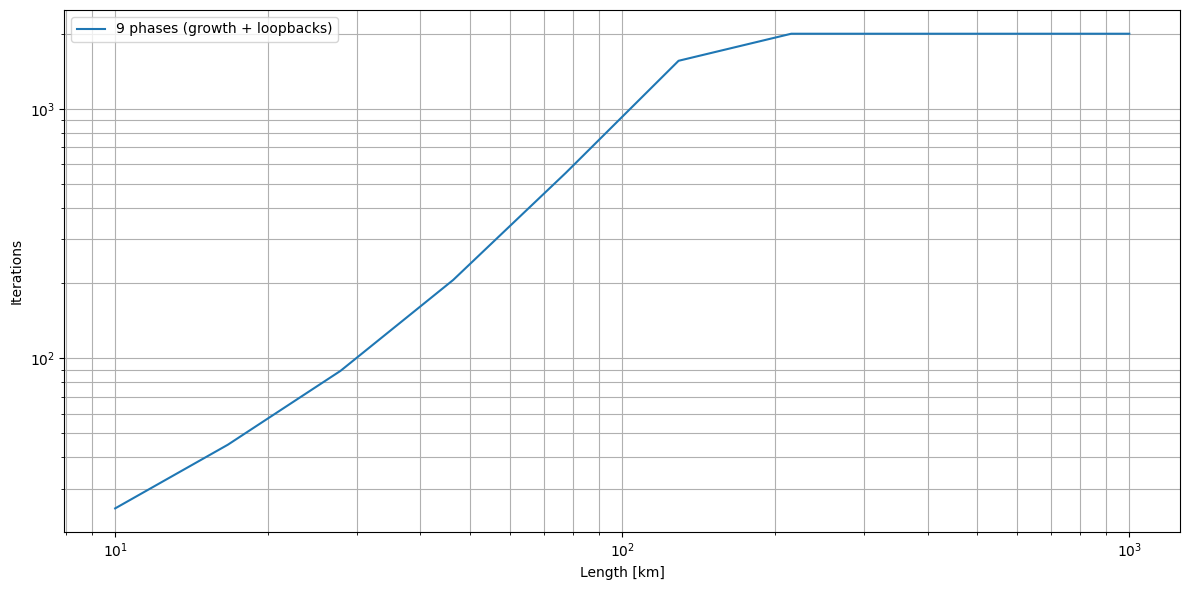

In [21]:
iterations_unified = np.zeros(len(As))
for i, Ai in enumerate(As):
    ttw = data - Ai @ data
    x, iters, *_ = solver.solve(A=Ai, b=ttw, rtol=1e-6, max_iters=2000, progress_bar=True, M=M)
    iterations_unified[i] = iters

plt.figure()
plt.plot(np.logspace(1, 3, 10), iterations_unified, label=f"{PHASES} phases (growth + loopbacks)")

plt.xlabel("Length [km]")
plt.ylabel("Iterations")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
